# Monte Carlo Pricing of European Options under Black–Scholes

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from montecarlo import (
 monte_carlo_call,
 monte_carlo_put,
 black_scholes_call,
 black_scholes_put
)

In [3]:
S = 100     # Current stock price
K = 105     # Strike price
T = 1       # Time to maturity (in years)
r = 0.05    # Risk-free rate (annual, continuously compounded)
sigma = 0.2 # Volatility (annual standard deviation)

### Geometric Brownian Motion

Under the Black–Scholes framework, the stock price $S_t$ is assumed to follow a **Geometric Brownian Motion (GBM)**:

$$
dS_t = \mu S_t \, dt + \sigma S_t \, dW_t
$$

where:

- $S_t$ is the stock price at time $t$
- $\mu$ is the drift (expected return)
- $\sigma$ is the volatility
- $W_t$ is a standard Brownian motion

---

Under the **risk-neutral measure**, the drift $\mu$ is replaced by the risk-free rate $r$.  
The closed-form solution of the GBM then gives the terminal price:

$$
S_T = S_0 \exp\Big((r - \tfrac{1}{2}\sigma^2)T + \sigma \sqrt{T} Z\Big)
$$

where:

- $Z \sim \mathcal{N}(0,1)$
- $r$ is the continuously compounded risk-free rate
- $T$ is the time to maturity

This expression is used to simulate terminal prices in the Monte Carlo framework.

In [7]:
bs_call_price = black_scholes_call(S, K, T, r, sigma)
bs_put_price = black_scholes_put(S, K, T, r, sigma)
print(f"Black-Scholes Call Price: {bs_call_price:.4f}")
print(f"Black-Scholes Put Price: {bs_put_price:.4f}")

Black-Scholes Call Price: 8.0214
Black-Scholes Put Price: 7.9004


The analytical Black–Scholes prices serve as a benchmark for validating the Monte Carlo estimator.

In [10]:
parity_lhs = bs_call_price - bs_put_price
parity_rhs = S - K * np.exp(-r * T)

print("\nPut–Call Parity Check:")
print(f"LHS (C - P): {parity_lhs:.4f}")
print(f"RHS (S - K e^(-rT)): {parity_rhs:.4f}")


Put–Call Parity Check:
LHS (C - P): 0.1209
RHS (S - K e^(-rT)): 0.1209


In [12]:
price, se = monte_carlo_call(S, K, T, r, sigma)
put_price, put_se = monte_carlo_put(S, K, T, r, sigma)
print(f"Monte Carlo Call Price: {price:.2f} (SE: {se:.6f})")
print(f"Monte Carlo Put Price: {put_price:.2f} (SE: {put_se:.6f})")
print("\n95% Confidence Intervals:")
print(f"Call: [{price - 1.96*se:.4f}, {price + 1.96*se:.4f}]")
print(f"Put:  [{put_price - 1.96*put_se:.4f}, {put_price + 1.96*put_se:.4f}]")

Monte Carlo Call Price: 8.07 (SE: 0.041811)
Monte Carlo Put Price: 7.91 (SE: 0.032788)

95% Confidence Intervals:
Call: [7.9886, 8.1525]
Put:  [7.8443, 7.9728]


The Monte Carlo estimates are reported with standard errors to quantify sampling uncertainty.

### Put–Call Parity Check

To validate both the analytical and Monte Carlo implementations, we verify the **put–call parity** relationship for European options:

$$
C - P = S_0 - K e^{-rT}
$$

where:

- $C$ is the call price  
- $P$ is the put price  
- $S_0$ is the current stock price  
- $K$ is the strike price  
- $r$ is the continuously compounded risk-free rate  
- $T$ is time to maturity  

Under no-arbitrage conditions, this identity must hold. Any deviation in the Monte Carlo results should fall within the statistical confidence interval implied by the standard error.

In [16]:
lhs = price - put_price
rhs = S - K * np.exp(-r * T)

# Standard error of (C - P)
parity_se = np.sqrt(se**2 + put_se**2)

print("Put–Call Parity Check (Monte Carlo)")
print(f"LHS (C - P): {lhs:.4f}")
print(f"RHS (S - K e^(-rT)): {rhs:.4f}")
print(f"Difference: {lhs - rhs:.6f}")
print(f"Standard Error of Difference: {parity_se:.6f}")

print("\n95% Confidence Interval for (C - P):")
print(f"[{lhs - 1.96*parity_se:.4f}, {lhs + 1.96*parity_se:.4f}]")

Put–Call Parity Check (Monte Carlo)
LHS (C - P): 0.1620
RHS (S - K e^(-rT)): 0.1209
Difference: 0.041070
Standard Error of Difference: 0.053133

95% Confidence Interval for (C - P):
[0.0578, 0.2661]


The observed discrepancy arises from Monte Carlo sampling error. 
Given that the deviation lies within two standard errors of zero, 
it is not statistically significant. As the number of simulations 
increases, this error should decrease at a rate proportional to 
$1/\sqrt{N}$.

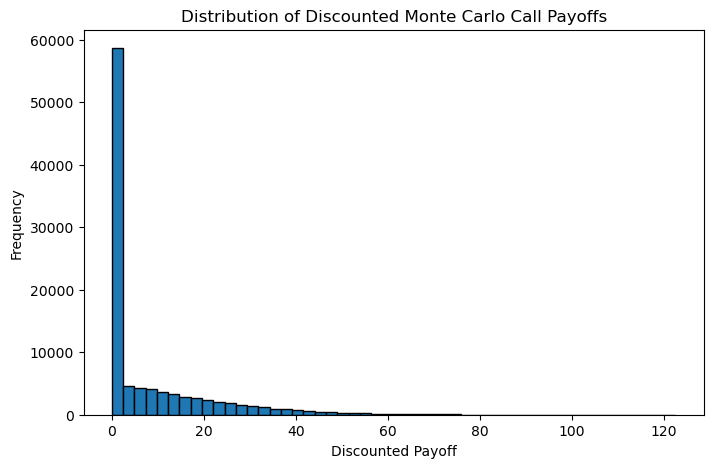

In [19]:
# Simulate terminal stock prices
Z = np.random.standard_normal(100000)
ST = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

# Compute discounted call payoffs
payoff = np.maximum(ST - K, 0)
discounted_payoff = np.exp(-r * T) * payoff

plt.figure(figsize=(8, 5))
plt.hist(discounted_payoff, bins=50, edgecolor='black')
plt.title("Distribution of Discounted Monte Carlo Call Payoffs")
plt.xlabel("Discounted Payoff")
plt.ylabel("Frequency")
plt.show()

The payoff distribution is highly right-skewed. 
A large proportion of simulations result in zero payoff (out-of-the-money), 
while a small number generate large positive payoffs. 
This skewness explains why Monte Carlo estimators may require a large number 
of simulations to achieve low variance.

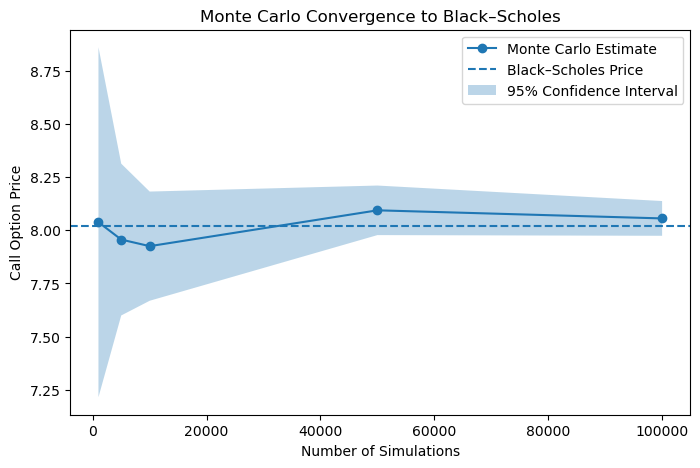

In [22]:
simulations = [1000, 5000, 10000, 50000, 100000]

mc_prices = []
lower_bounds = []
upper_bounds = []

for n in simulations:
    price, se = monte_carlo_call(S, K, T, r, sigma, n)

    mc_prices.append(price)
    lower_bounds.append(price - 1.96 * se)
    upper_bounds.append(price + 1.96 * se)

plt.figure(figsize=(8, 5))

plt.plot(simulations, mc_prices, marker='o', label="Monte Carlo Estimate")
plt.axhline(y=bs_call_price, linestyle='--', label="Black–Scholes Price")

plt.fill_between(simulations, lower_bounds, upper_bounds, alpha=0.3, label="95% Confidence Interval")

plt.xlabel("Number of Simulations")
plt.ylabel("Call Option Price")
plt.title("Monte Carlo Convergence to Black–Scholes")
plt.legend()
plt.show()

As the number of simulations increases, the Monte Carlo estimator 
converges to the Black–Scholes analytical price. The confidence 
interval narrows at a rate proportional to $1/\sqrt{N}$, 
illustrating the standard convergence behaviour of Monte Carlo methods.

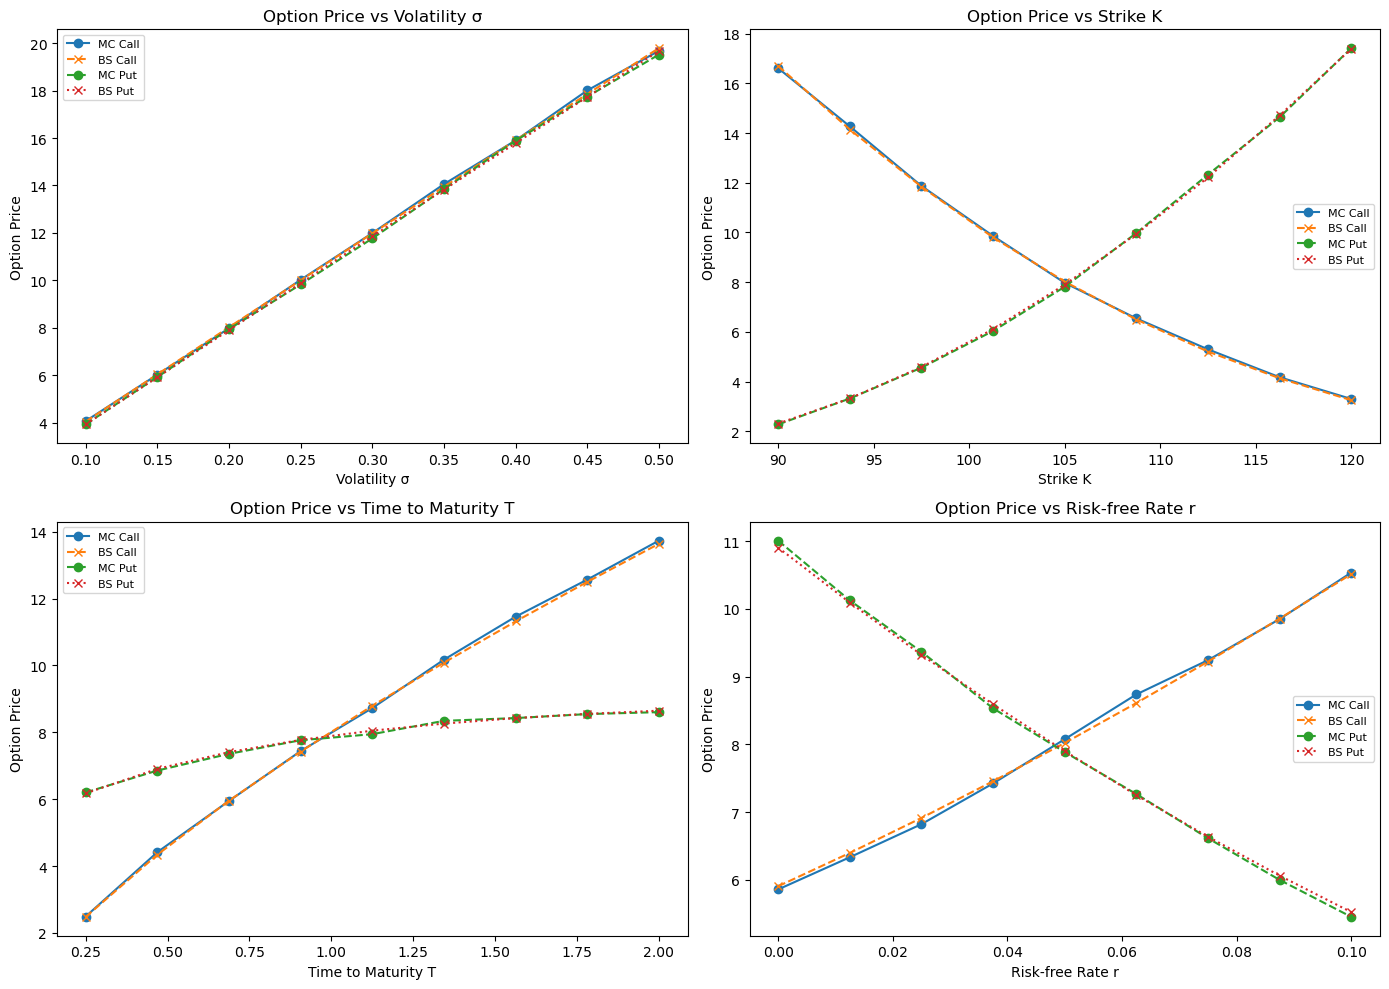

In [25]:
# Baseline parameters
S, K, T, r, sigma = 100, 105, 1, 0.05, 0.2

# Parameters to vary
vols = np.linspace(0.1, 0.5, 9)
strikes = np.linspace(90, 120, 9)
maturities = np.linspace(0.25, 2, 9)
rates = np.linspace(0, 0.1, 9)

param_values = [vols, strikes, maturities, rates]
param_names = ['Volatility σ', 'Strike K', 'Time to Maturity T', 'Risk-free Rate r']

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

for i, ax in enumerate(axs.flatten()):
    x = param_values[i]

    mc_call_prices = []
    bs_call_prices = []
    mc_put_prices = []
    bs_put_prices = []

    for v in x:

        if i == 0:  # Volatility
            mc_call, _ = monte_carlo_call(S, K, T, r, sigma=v, num_simulations=50000)
            mc_put, _  = monte_carlo_put(S, K, T, r, sigma=v, num_simulations=50000)

            bs_call = black_scholes_call(S, K, T, r, sigma=v)
            bs_put  = black_scholes_put(S, K, T, r, sigma=v)

        elif i == 1:  # Strike
            mc_call, _ = monte_carlo_call(S, v, T, r, sigma, num_simulations=50000)
            mc_put, _  = monte_carlo_put(S, v, T, r, sigma, num_simulations=50000)

            bs_call = black_scholes_call(S, v, T, r, sigma)
            bs_put  = black_scholes_put(S, v, T, r, sigma)

        elif i == 2:  # Maturity
            mc_call, _ = monte_carlo_call(S, K, v, r, sigma, num_simulations=50000)
            mc_put, _  = monte_carlo_put(S, K, v, r, sigma, num_simulations=50000)

            bs_call = black_scholes_call(S, K, v, r, sigma)
            bs_put  = black_scholes_put(S, K, v, r, sigma)

        else:  # Risk-free rate
            mc_call, _ = monte_carlo_call(S, K, T, v, sigma, num_simulations=50000)
            mc_put, _  = monte_carlo_put(S, K, T, v, sigma, num_simulations=50000)

            bs_call = black_scholes_call(S, K, T, v, sigma)
            bs_put  = black_scholes_put(S, K, T, v, sigma)

        mc_call_prices.append(mc_call)
        bs_call_prices.append(bs_call)
        mc_put_prices.append(mc_put)
        bs_put_prices.append(bs_put)

    ax.plot(x, mc_call_prices, 'o-', label='MC Call')
    ax.plot(x, bs_call_prices, 'x--', label='BS Call')
    ax.plot(x, mc_put_prices, 'o--', label='MC Put')
    ax.plot(x, bs_put_prices, 'x:', label='BS Put')

    ax.set_title(f"Option Price vs {param_names[i]}")
    ax.set_xlabel(param_names[i])
    ax.set_ylabel("Option Price")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

The sensitivity analysis confirms the expected theoretical relationships:

- Option values increase with volatility.
- Call prices decrease with strike, while put prices increase.
- Option values increase with time to maturity.
- Call prices increase with interest rates, while put prices decrease.

Monte Carlo and Black–Scholes curves align closely across all parameter ranges.

## Conclusion

This project implemented Monte Carlo simulation to price European call and put options under the Black–Scholes framework. 

The Monte Carlo estimates converge to the analytical Black–Scholes prices as the number of simulations increases, with error decreasing at the expected rate of $1/\sqrt{N}$. 

Put–call parity was verified numerically and deviations were shown to be statistically insignificant within confidence intervals.

Sensitivity analysis confirmed the expected monotonic relationships between option prices and key parameters such as volatility, strike, maturity, and interest rates.

Overall, the numerical implementation is consistent with theoretical results.